# 06 — Resume training and select the best validation checkpoint

Notebook 5 showed that Bengal recall was the main weakness. This experiment resumes the epoch-5 model for five more epochs, using a smaller learning rate. After every epoch we measure validation performance and save the **best** model selected from validation data. The official test split is not loaded.

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SELECTED_CLASSES = ['Abyssinian', 'Bengal', 'Egyptian Mau']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
print('This experiment resumes the saved epoch-5 model; it does not start from scratch.')

PyTorch: 2.13.0+cpu
Device:  cpu
This experiment resumes the saved epoch-5 model; it does not start from scratch.


In [2]:
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / 'pyproject.toml').exists() else CURRENT_FOLDER.parent
METADATA_PATH = PROJECT_ROOT / 'data' / 'classification_crops' / 'metadata.csv'
START_CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_epoch5.pt'
BEST_CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_best_epoch6_to_10.pt'

assert METADATA_PATH.exists(), f'Missing crop metadata: {METADATA_PATH}'
assert START_CHECKPOINT_PATH.exists(), f'Missing starting checkpoint: {START_CHECKPOINT_PATH}'
records = pd.read_csv(METADATA_PATH)
train_records = records.query("split == 'train'").reset_index(drop=True)
val_records = records.query("split == 'val'").reset_index(drop=True)

assert len(train_records) == 232 and len(val_records) == 58
print(f'Training crops:   {len(train_records)}')
print(f'Validation crops: {len(val_records)}')
print('The 294 official test crops are intentionally not loaded.')

Training crops:   232
Validation crops: 58
The 294 official test crops are intentionally not loaded.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PetCropDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(PROJECT_ROOT / row['crop_path']) as image:
            image = image.convert('RGB')
        return self.transform(image), int(row['label_id'])

train_loader = DataLoader(PetCropDataset(train_records, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(PetCropDataset(val_records, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Training batches: {len(train_loader)}; validation batches: {len(val_loader)}')

Training batches: 15; validation batches: 4


In [4]:
starting_checkpoint = torch.load(START_CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
assert starting_checkpoint['class_names'] == SELECTED_CLASSES

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(SELECTED_CLASSES))
model.load_state_dict(starting_checkpoint['model_state_dict'])
model = model.to(DEVICE)

for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.fc.parameters():
    parameter.requires_grad = True

history = list(starting_checkpoint['history'])
print(f"Starting from saved epoch {history[-1]['epoch']}.")
print(f"Saved validation accuracy: {history[-1]['val_accuracy']:.1%}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Starting from saved epoch 5.
Saved validation accuracy: 81.0%
Trainable parameters: 1,539


## A smaller learning rate

The first five epochs used `0.001`. This experiment uses `0.0003`: the model has already learned something useful, so we take smaller update steps rather than making large changes that could erase it.

In [5]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=3e-4, weight_decay=1e-4)

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = loss_function(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

print('Training updates only model.fc. Evaluation measures validation performance without changing weights.')

Training updates only model.fc. Evaluation measures validation performance without changing weights.


In [6]:
baseline_val_loss, baseline_val_accuracy = evaluate(model, val_loader)
best_epoch = history[-1]['epoch']
best_val_accuracy = baseline_val_accuracy
best_val_loss = baseline_val_loss

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': SELECTED_CLASSES,
    'image_size': 224,
    'history': history.copy(),
    'best_epoch': best_epoch,
    'best_val_accuracy': best_val_accuracy,
    'best_val_loss': best_val_loss,
    'training_setup': 'ResNet18 pretrained; feature extractor frozen; final layer resumed with learning rate 0.0003',
}, BEST_CHECKPOINT_PATH)

print(f'Epoch {best_epoch} checkpoint re-check: validation accuracy={baseline_val_accuracy:.1%}, loss={baseline_val_loss:.3f}')
print('Epoch 5 is saved as the starting best model. New epochs must beat it to replace it.')

Epoch 5 checkpoint re-check: validation accuracy=81.0%, loss=0.624
Epoch 5 is saved as the starting best model. New epochs must beat it to replace it.


## Train epochs 6–10 and save the best one

The rule is written down before we look at new results: choose higher validation accuracy; if accuracy ties, choose lower validation loss. This makes model selection explicit rather than choosing whichever result feels nicest.

In [7]:
START_EPOCH = best_epoch + 1
FINAL_EPOCH = 10
start_time = time.perf_counter()

for epoch in range(START_EPOCH, FINAL_EPOCH + 1):
    train_loss, train_accuracy = train_one_epoch(model, train_loader)
    val_loss, val_accuracy = evaluate(model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'val_loss': val_loss, 'val_accuracy': val_accuracy})

    is_better = (val_accuracy > best_val_accuracy) or (val_accuracy == best_val_accuracy and val_loss < best_val_loss)
    if is_better:
        best_epoch, best_val_accuracy, best_val_loss = epoch, val_accuracy, val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': SELECTED_CLASSES,
            'image_size': 224,
            'history': history.copy(),
            'best_epoch': best_epoch,
            'best_val_accuracy': best_val_accuracy,
            'best_val_loss': best_val_loss,
            'training_setup': 'ResNet18 pretrained; feature extractor frozen; final layer resumed with learning rate 0.0003',
        }, BEST_CHECKPOINT_PATH)
        marker = '  <-- saved as new best'
    else:
        marker = ''
    print(f'Epoch {epoch}: train={train_accuracy:.1%}, validation={val_accuracy:.1%}, val loss={val_loss:.3f}{marker}')

history_frame = pd.DataFrame(history)
print(f'Additional training took {time.perf_counter() - start_time:.1f} seconds.')
print(f'Best selected epoch: {best_epoch}; validation accuracy={best_val_accuracy:.1%}; loss={best_val_loss:.3f}')
print(f'Best-checkpoint file exists: {BEST_CHECKPOINT_PATH.exists()}')

Epoch 6: train=85.8%, validation=82.8%, val loss=0.604  <-- saved as new best
Epoch 7: train=89.2%, validation=82.8%, val loss=0.604  <-- saved as new best
Epoch 8: train=84.5%, validation=81.0%, val loss=0.596
Epoch 9: train=89.7%, validation=81.0%, val loss=0.581
Epoch 10: train=89.2%, validation=79.3%, val loss=0.586
Additional training took 153.1 seconds.
Best selected epoch: 7; validation accuracy=82.8%; loss=0.604
Best-checkpoint file exists: True


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.078,0.440,0.942,0.552
1,2,0.811,0.677,0.805,0.655
2,3,0.633,0.823,0.720,0.793
3,4,0.558,0.823,0.730,0.603
4,5,0.535,0.802,0.624,0.810
5,6,0.465,0.858,0.604,0.828
6,7,0.434,0.892,0.604,0.828
7,8,0.461,0.845,0.596,0.810
8,9,0.393,0.897,0.581,0.810
9,10,0.426,0.892,0.586,0.793


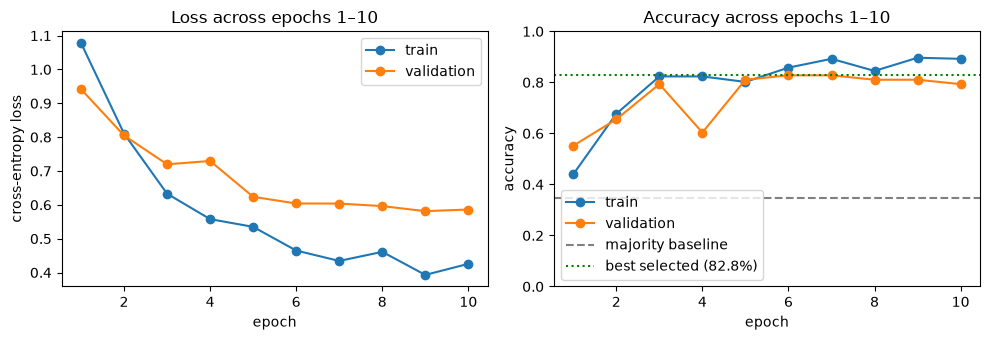

The selected checkpoint is based only on validation data. The test set is still untouched.


In [8]:
display(history_frame.round(3))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_frame['epoch'], history_frame['train_loss'], marker='o', label='train')
axes[0].plot(history_frame['epoch'], history_frame['val_loss'], marker='o', label='validation')
axes[0].set(title='Loss across epochs 1–10', xlabel='epoch', ylabel='cross-entropy loss')
axes[0].legend()
axes[1].plot(history_frame['epoch'], history_frame['train_accuracy'], marker='o', label='train')
axes[1].plot(history_frame['epoch'], history_frame['val_accuracy'], marker='o', label='validation')
axes[1].axhline(0.345, color='gray', linestyle='--', label='majority baseline')
axes[1].axhline(best_val_accuracy, color='green', linestyle=':', label=f'best selected ({best_val_accuracy:.1%})')
axes[1].set(title='Accuracy across epochs 1–10', xlabel='epoch', ylabel='accuracy', ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()
print('The selected checkpoint is based only on validation data. The test set is still untouched.')

### Stop and inspect

Send the epoch-by-epoch output, selected-best line, and chart. We will compare the selected checkpoint with epoch 5 before deciding whether to change the model further.